In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("/Users/minime/Downloads/SCMS_Delivery_History.csv")
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10324
Columns: 33


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [8]:
df.describe()

,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


In [9]:
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

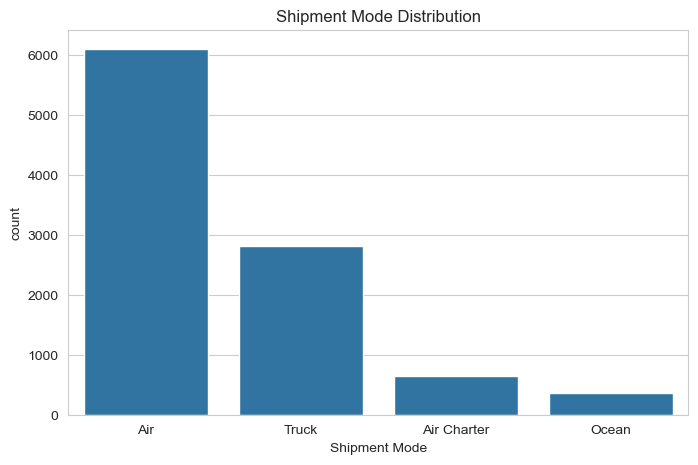

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Shipment Mode',
    order=df['Shipment Mode'].value_counts().index)
plt.title("Shipment Mode Distribution")
plt.show()

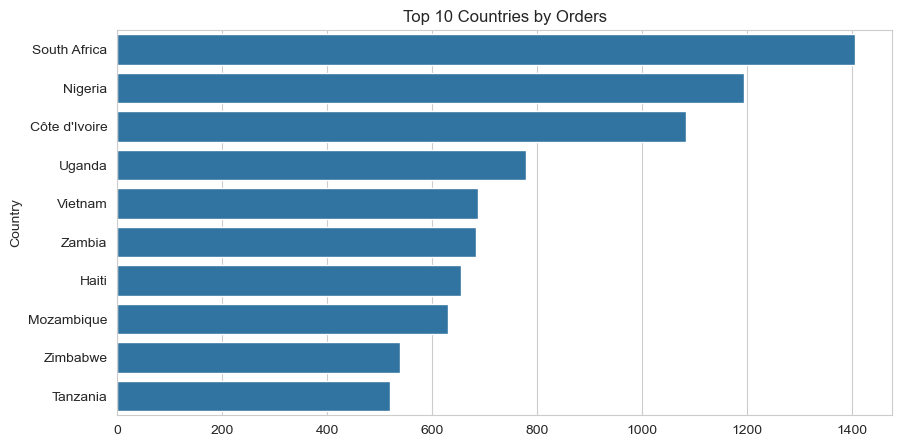

In [11]:
top_country = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_country.values,
    y=top_country.index)

plt.title("Top 10 Countries by Orders")
plt.show()

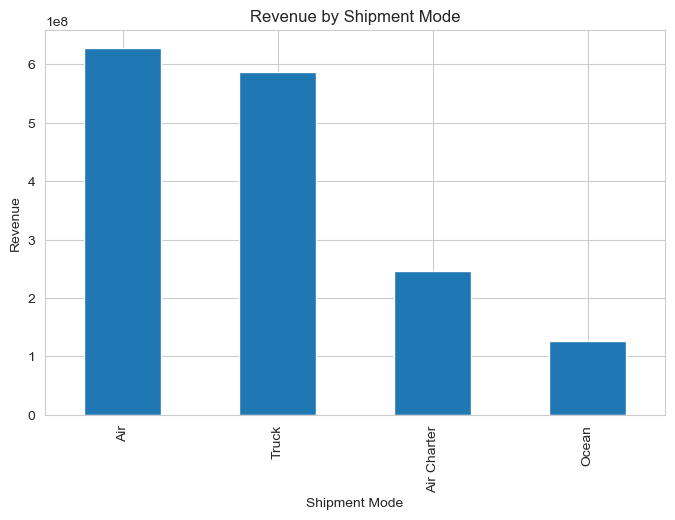

In [12]:
shipment_revenue = (
    df.groupby('Shipment Mode')['Line Item Value']
      .sum()
      .sort_values(ascending=False))

shipment_revenue.plot(
    kind='bar',
    figsize=(8,5))

plt.title("Revenue by Shipment Mode")
plt.ylabel("Revenue")
plt.show()

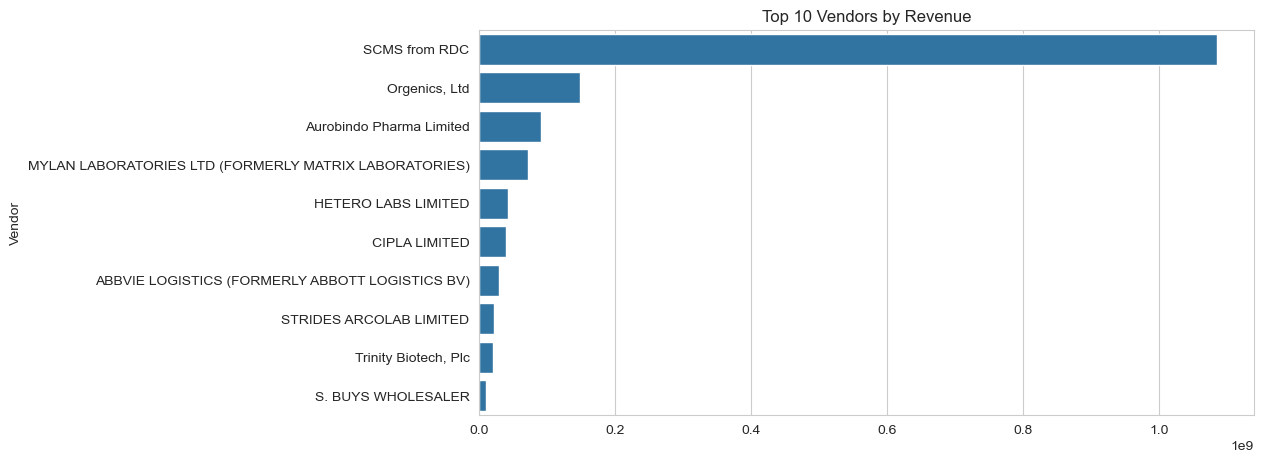

In [13]:
vendor_sales = (
    df.groupby('Vendor')['Line Item Value']
      .sum()
      .sort_values(ascending=False)
      .head(10))

plt.figure(figsize=(10,5))

sns.barplot(
    x=vendor_sales.values,
    y=vendor_sales.index)

plt.title("Top 10 Vendors by Revenue")
plt.show()

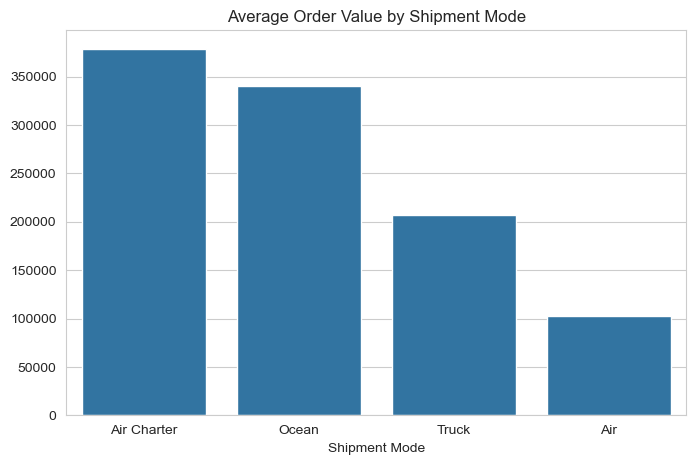

In [14]:
avg_order = (
    df.groupby('Shipment Mode')['Line Item Value']
      .mean()
      .sort_values(ascending=False))

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_order.index,
    y=avg_order.values)

plt.title("Average Order Value by Shipment Mode")
plt.show()

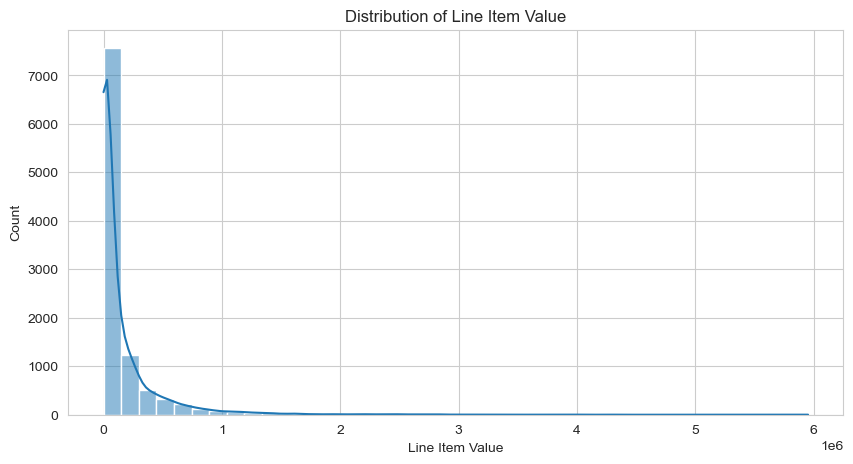

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Line Item Value'],
    bins=40,
    kde=True)

plt.title("Distribution of Line Item Value")
plt.show()

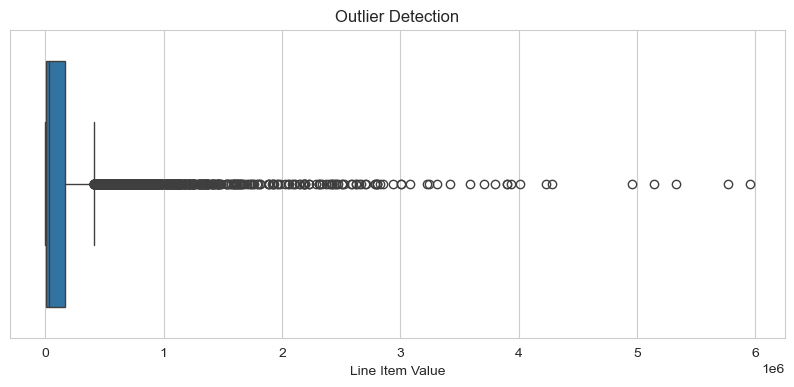

In [16]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['Line Item Value'])

plt.title("Outlier Detection")
plt.show()

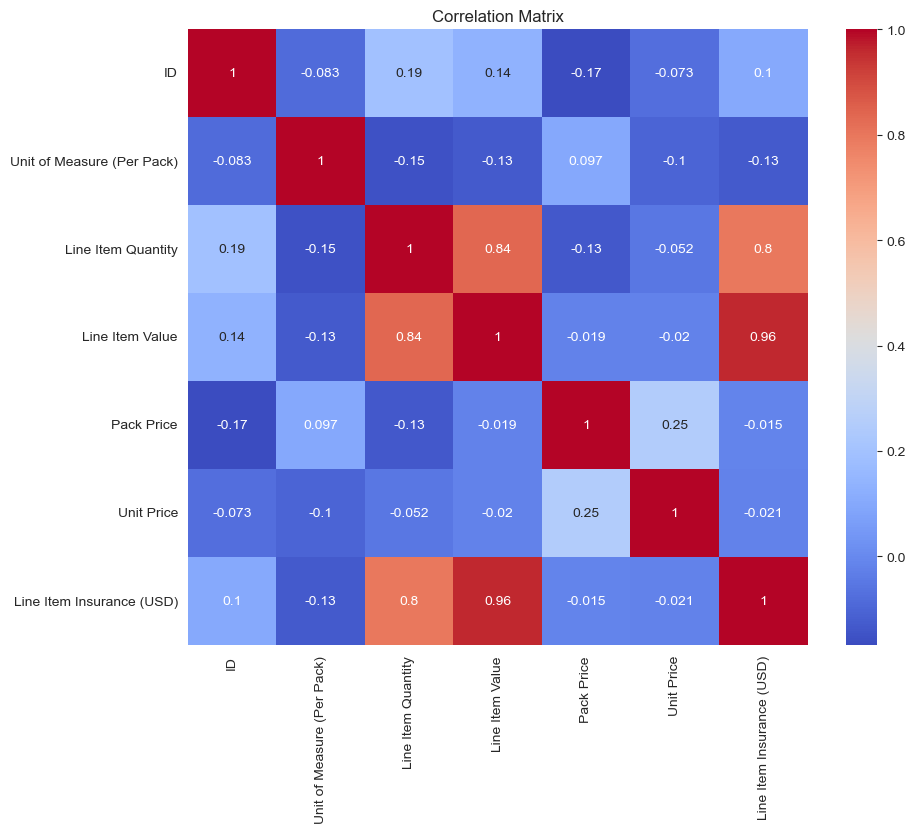

In [17]:
numeric_df = df.select_dtypes(
    include=['int64','float64'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()